<a href="https://colab.research.google.com/github/Swapna-2025/Airbnb-Analysis/blob/main/Airbnb_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**"Airbnb"** Data Analysis explores pricing trends, neighborhood demand, and room preferences using Exploratory Data Analysis (EDA). This project uncovers key insights to help travelers find the best stays and hosts maximize their earnings.

# **1.$~~$Importing the necessary libraries for Exploratory Data Analysis (EDA):-**

The following libraries will be used for performing Exploratory Data Analysis (EDA) on the given airbnb dataset....

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import folium
from folium.plugins import MarkerCluster
from folium import plugins
from folium.plugins import FastMarkerCluster
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
sns.set(color_codes=True)

# **2.$~~$Loading Data into a Pandas DataFrame:-**


Loading data into a Pandas DataFrame is a crucial step in Exploratory Data Analysis (EDA). Since the dataset is in CSV format with comma-separated values, we can simply read it using Pandas, which efficiently handles the task...

In [ ]:
df=pd.read_csv('airbnb.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
# To get there are how many rows and columns
df.shape

(48895, 16)

In [ ]:
# To read top 5 rows
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# To view last 5 rows
df.tail(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


# **3.$~~$Checking Data Types of Each Columns:-**

It’s important to check the data types because sometimes values like the price,id  might be stored as text instead of numbers. If that happens, we need to convert them to integers to create graphs correctly. In this case, the data is already in the correct format, so no changes are needed...

In [ ]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
room_type,object
price,int64
minimum_nights,int64
number_of_reviews,int64


In [ ]:
# Find if there is any missing values or not, if yes then handle those missing values
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


⚫$~~$So, it is found that there are many missing values in some columns.
   
   $~~$ Check it

   $~~$   name-16

  $~~$ host_name-21

  $~~$ last_review-10052

  $~~$ reviews_per_month-10052

  $~~$ Let's fix it....

In [ ]:
df.fillna(method='ffill', inplace=True)
df[['name','host_name','last_review','reviews_per_month']].isna().sum()

<ipython-input-8-b3de670a552d>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,0
name,0
host_name,0
last_review,0
reviews_per_month,0


In [ ]:
# Find if there is any duplicate values or not
df.duplicated().sum()

0

*$~~$ There is no duplicate values.

In [ ]:
# To show basic statisticals characteristics of the data
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.395810,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.681327,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.200000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.790000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.000000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# To see the distribution of categorical column
df.value_counts()

,,,,,,,,,,,,,,count
id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,1
25583366,Upper East Side entire flat - Close to Subway,14073337,Marc & Youna,Manhattan,Upper East Side,Entire home/apt,180,4,9,2019-05-26,0.71,1,4,1
25551687,Perfect room in Williamsburg (10min to Manhattan),889683,Rachel,Brooklyn,Williamsburg,Private room,84,1,95,2019-06-15,7.13,2,51,1
25552076,Private Garden. Trendy Williamsburg location!,184009385,Artem,Brooklyn,Williamsburg,Entire home/apt,170,2,47,2019-06-20,3.70,2,57,1
25554120,Cozy and modern one Bedroom Apartment,192793716,Claudia,Manhattan,Upper East Side,Entire home/apt,149,30,25,2019-06-04,2.01,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13121809,Spacious Sunny One Bed in Williamsburg,24370211,Yety,Brooklyn,Williamsburg,Entire home/apt,80,10,2,2017-01-07,0.05,2,0,1
13122135,Room in BIG art-filled space in prime Brooklyn,9793190,Rebecca,Brooklyn,Greenpoint,Private room,80,1,4,2018-02-25,0.24,1,0,1
13122318,2bdrm apt w/private backyard in Artsy Bushwick,2689908,Emily,Brooklyn,Bushwick,Entire home/apt,59,2,177,2019-06-24,4.74,1,3,1


# **4.$~~$ Let's see distribution of price range:-**

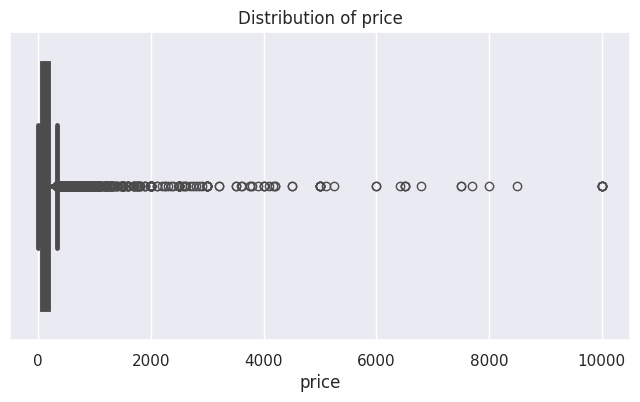

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["price"], linewidth=3.5)
plt.title('Distribution of price')
plt.xlabel('price')
plt.show()

**⚛$~~$ But there are so much outliers, as 'price' column is very precious so we should find out those outliers and correct the analysis**

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

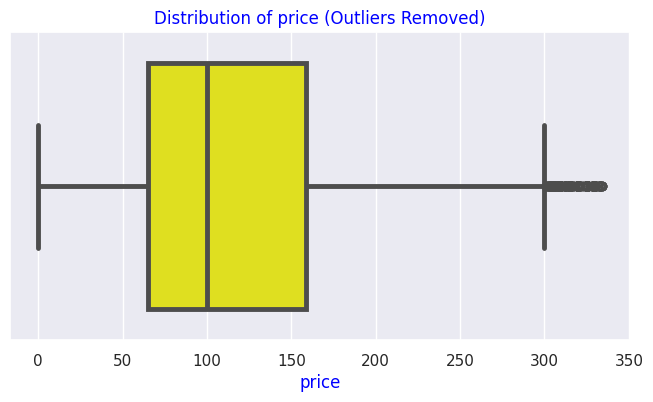

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_filtered["price"], linewidth=3.5, color='yellow',)
plt.title('Distribution of price (Outliers Removed)', color='blue')
plt.xlabel('price', color='blue')
plt.show()

In [ ]:
max_price = df_filtered['price'].max()
print(max_price)

334


⚫$~~$ ***Key observation from 'Distribution of price' :-***

▶$~~$ The majority of Airbnb listing prices fall between approximately  (\$55  and \$155) .

▶$~~$ The maximum price for typical listings is around (\$334) .

# **5.$~~$ Distribution of reviews per month:-**

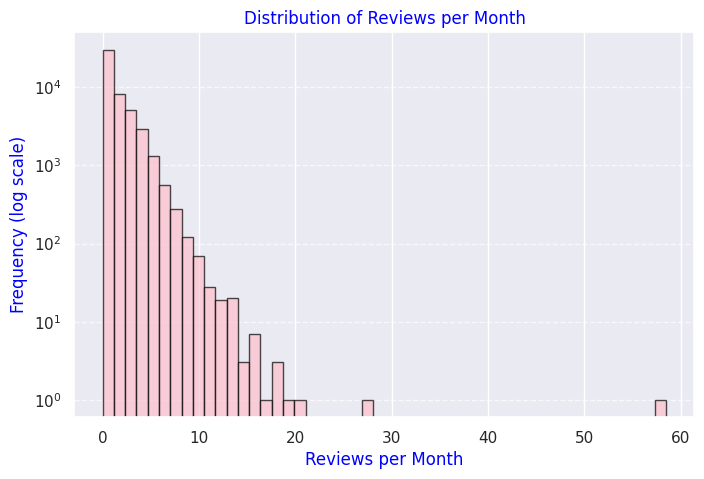

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['reviews_per_month'], bins=50, edgecolor='black',color='pink' ,alpha=0.7, log=True)
plt.xlabel('Reviews per Month' ,color='blue')
plt.ylabel('Frequency (log scale)', color='blue')
plt.title('Distribution of Reviews per Month', color='blue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

⚫$~~$ ***Key observation fron "Distribution of reviews per month" histplot:-***

▶$~~$ The highest concentration is near 0-2 reviews per month, indicating that many properties are not frequently reviewed.


▶$~~$ There is a long tail with fewer high-review in the right side of the histogram.


▶$~~$  A small number of listings receive 10+ reviews per month, which may indicate very high-demand properties or frequent short stays.

# **6.$~~$ Finding Total count of each room types:-**

In [ ]:
# Finding unique values from column 'room_type'
room_type = df.room_type.unique()
room_type

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [ ]:
# Distribution of different room type
roomtype_frequency = dict(df.room_type.value_counts())
roomtype_frequency

{'Entire home/apt': 25409, 'Private room': 22326, 'Shared room': 1160}

Text(0.5, 1.0, 'Count of Listed Rooms')

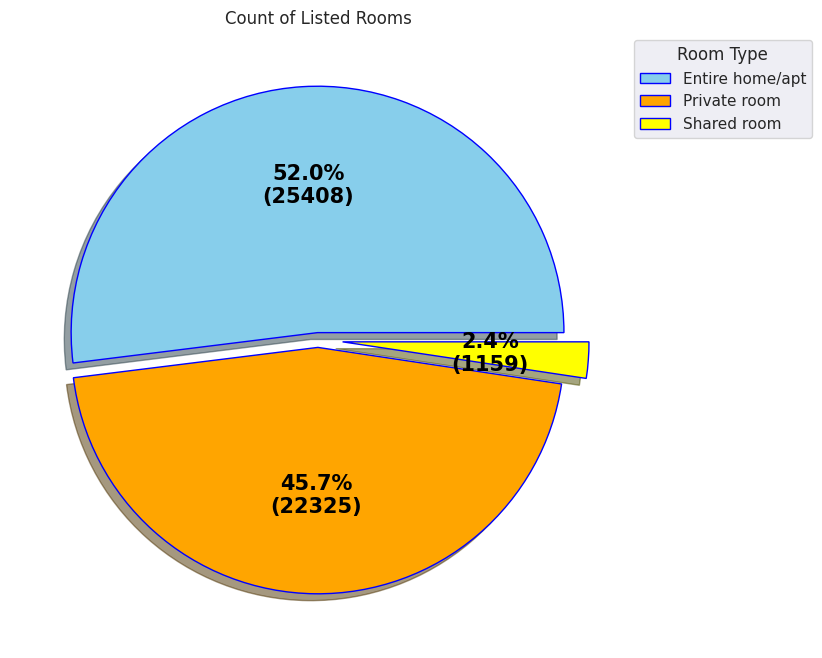

In [ ]:
room_type = list(roomtype_frequency.keys())
data = list(roomtype_frequency.values())
colors = ("skyblue", "orange", "yellow",)
explode = (0.03, 0.03, 0.1)
wp = {'linewidth':1, 'edgecolor':"blue" }
def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d})".format(pct, absolute)
fig,pie_chart = plt.subplots(figsize =(12, 8))
wedges, texts, autotexts =pie_chart.pie(data, autopct = lambda pct: func(pct, data),
                                                explode = explode,
                                                shadow = True,
                                                colors = colors,
                                                startangle = 0,
                                                wedgeprops = wp,
                                                textprops = dict(color ="black"))
pie_chart.legend(room_type,title ="Room Type",
                        loc ="upper left",
                        bbox_to_anchor=(1, 0., 0.,1))

plt.setp(autotexts, size = 15, weight = "bold")
pie_chart.set_title("Count of Listed Rooms")

⚫$~~$ Key Observation From 'Count of listed room' Pieplot:-

▶$~~$ Entire home/apt are the most common room types offered by Airbnb hosts (52% / 25408)

▶$~~$ Private rooms account for (45.7% / 22325) of listing.

▶$~~$ Shared rooms are considerably less common (2.4% / 1159).

# **7.$~~$ Finding Total Count Of Each Neighbourhood Group & Distribution Of Room Type In Each Neighbourhood Group:-**

In [ ]:
# Finding unique values from column 'neighbourhood_group'
neighbourhood_group = df.neighbourhood_group.unique()
neighbourhood_group

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [ ]:
# Distribution of each neighbourhood group
neighbourhood_group_frequency = dict(df.neighbourhood_group.value_counts())
neighbourhood_group_frequency

{'Manhattan': 21661,
 'Brooklyn': 20104,
 'Queens': 5666,
 'Bronx': 1091,
 'Staten Island': 373}

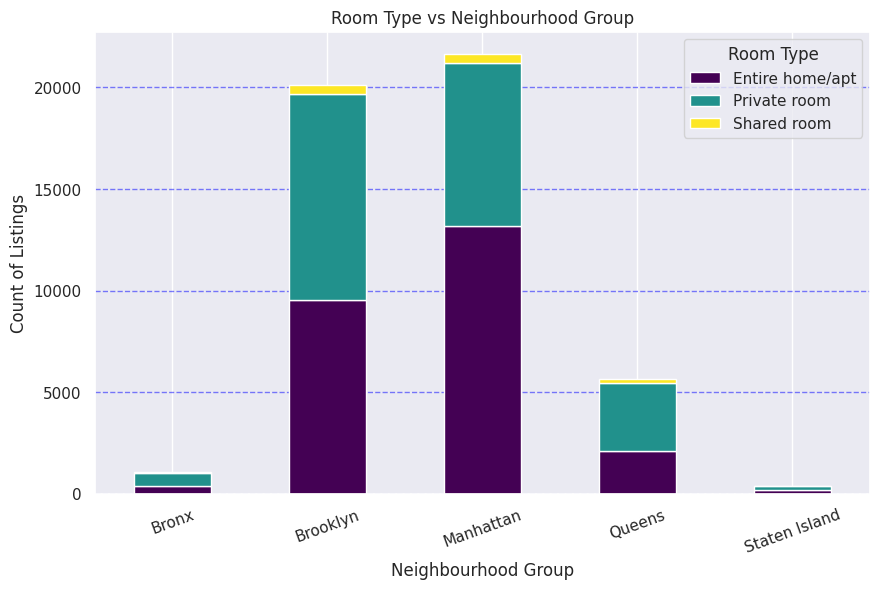

In [ ]:
room_neighbourhood_counts = df.groupby(["neighbourhood_group", "room_type"]).size().unstack()
room_neighbourhood_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count of Listings")
plt.title("Room Type vs Neighbourhood Group")
plt.legend(title="Room Type")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", color='blue', alpha=0.5)
plt.show()


⚫$~~$ ***Key observation from "Room type vs neighbourhood group" stacked bar chart:-***

▶$~~$  In 'Manhattan' neighbourhood group Entire home/Apt is the most dominant (13000).

▶$~~$ 'Private rooms' might be more common in Brooklyn and Queens.

▶$~~$ 'Shared rooms' have very small sections, it means they are not a popular choice in most neighbourhoods.
Some boroughs might not have any shared rooms at all such as 'Bronx' and 'Staten Island'.

▶$~~$ 'Manhattan' has more Airbnb listings overall.

# **8.$~~$ Finding Relation between neighbourhood group and availability of rooms According To Room Type:-**

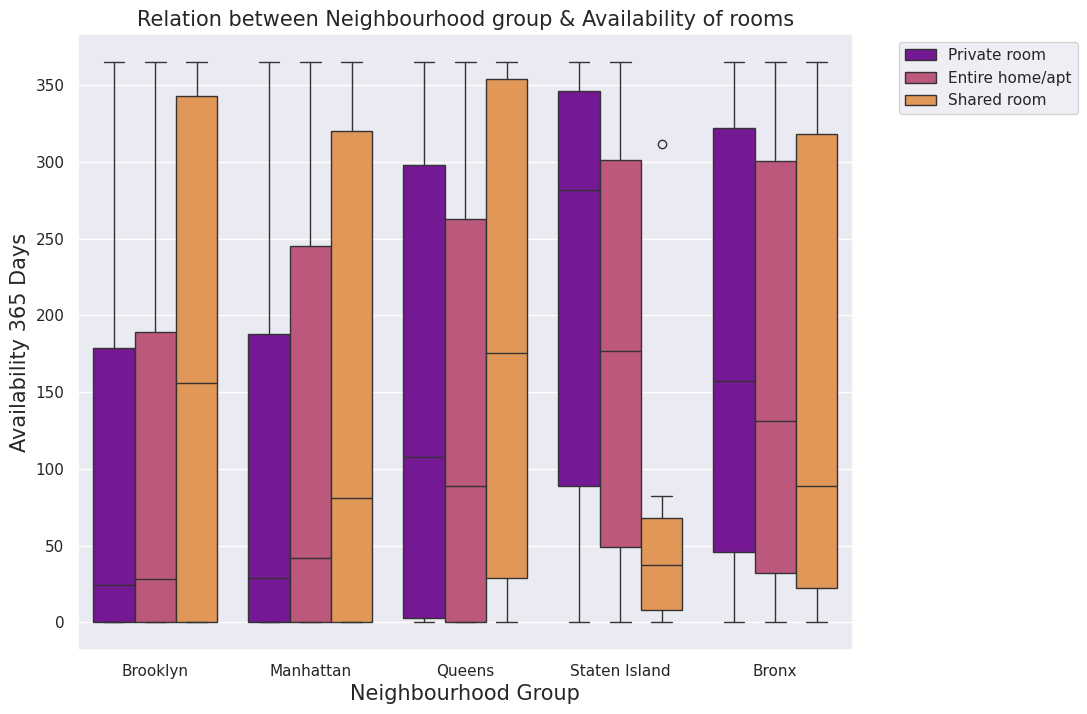

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x='neighbourhood_group',hue='room_type',y='availability_365',palette='plasma')
plt.title('Relation between Neighbourhood group & Availability of rooms').set_fontsize('15')
plt.ylabel('Availability 365 Days').set_fontsize('15')
plt.xlabel('Neighbourhood Group').set_fontsize('15')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

⚫$~~$ ***Key observation from 'Relation between Neighbourhood group & Availability of rooms' boxplot:-***

▶$~~$ Staten Island and the Bronx have the highest median availability of rooms for all types of accommodations.


▶$~~$ Manhattan and Brooklyn have relatively lower availability.

▶$~~$ In almost all neighborhoods, shared rooms tend to have higher availability compared to private rooms and entire homes/apartments.
This trend suggests that shared rooms are more frequently available throughout the year.

▶$~~$ The boxplots for entire home/apartments have a large range, showing that availability varies widely within the same neighborhood.

▶$~~$ Staten Island shows a distinct pattern where shared rooms have significantly lower availability compared to private rooms and entire apartments.

▶$~~$ The availability distribution for different room types in Brooklyn and Manhattan is more.


# **9.$~~$ Find Distribution of Airbnb Bookings Price Range:-**

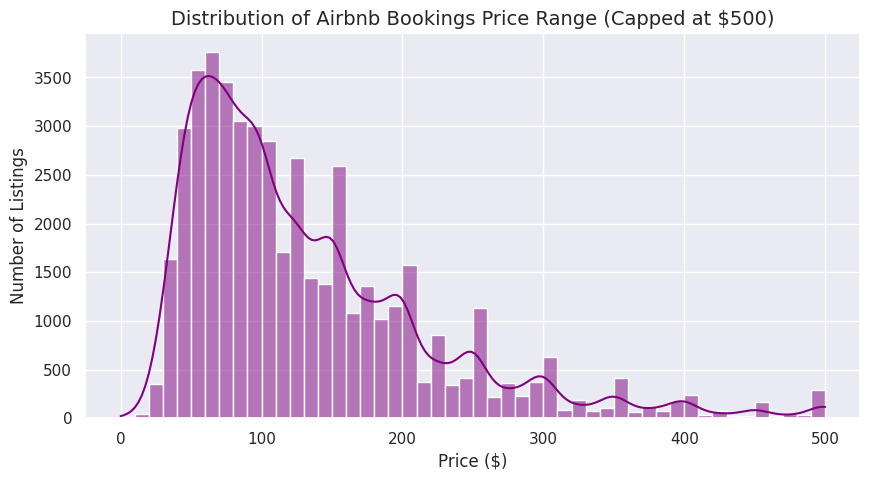

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] <= 500]['price'], bins=50, kde=True, color="purple")
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.title("Distribution of Airbnb Bookings Price Range (Capped at $500)", fontsize=14)
plt.grid(True)
plt.show()

⚫$~~$ ***Key observation from "Distribution of Airbnb Booking Prices' histplot:-***

▶$~~$ Most listings are priced between \$ 50 - \$ 200 per night.

▶$~~$ Mean price:- \$152.72

▶$~~$ Maximum price:- \$ 10000

# **10.$~~$ Find Average Price of Listings in Each Neighborhood Group and Neighborhood:-**

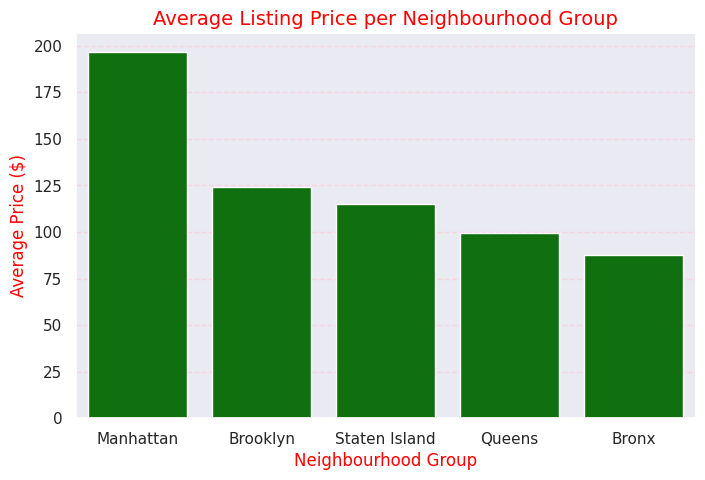

,price
neighbourhood_group,
Manhattan,196.875814
Brooklyn,124.383207
Staten Island,114.812332
Queens,99.517649
Bronx,87.496792


In [ ]:
avg_price_neighbourhood_group = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_price_neighbourhood_group.index, y=avg_price_neighbourhood_group.values, color='green')
plt.xlabel("Neighbourhood Group", fontsize=12, color='red')
plt.ylabel("Average Price ($)", fontsize=12, color='red')
plt.title("Average Listing Price per Neighbourhood Group", fontsize=14, color='red')
plt.grid(axis='y', linestyle='--', color='pink', alpha=0.5)
plt.show()
avg_price_neighbourhood_group

⚫$~~$ ***Key observation from "Average Listing Price per Neighbourhood Group" barplot:-***

▶$~~$  Neighbourhood group Manhattan has the highest average price (\$196.875814) per night.


▶$~~$ Brooklyn follows with (\$124.383207) per night.

▶$~~$ Bronx has the lowest average price near about (\$87.496792) per night.

▶$~~$ Staten Island has (\$114.812332) average price per night.

▶$~~$ Queens has (\$99.517649) average price per night.

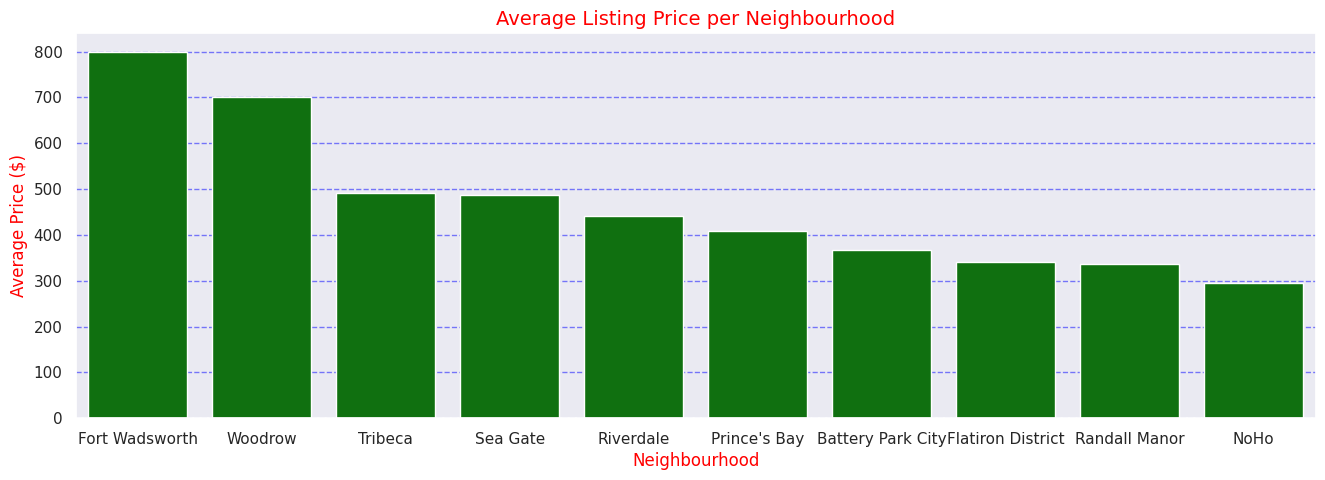

,price
neighbourhood,
Fort Wadsworth,800.000000
Woodrow,700.000000
Tribeca,490.638418
Sea Gate,487.857143
Riverdale,442.090909
Prince's Bay,409.500000
Battery Park City,367.557143
Flatiron District,341.925000
Randall Manor,336.000000


In [ ]:
avg_price_neighbourhood = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(16, 5))
sns.barplot(x=avg_price_neighbourhood.index, y=avg_price_neighbourhood.values, color='green')
plt.xlabel("Neighbourhood", fontsize=12,color='red')
plt.ylabel("Average Price ($)", fontsize=12, color='red')
plt.title("Average Listing Price per Neighbourhood", fontsize=14, color='red')
plt.grid(axis='y', linestyle='--', color='blue', alpha=0.5)
plt.show()
avg_price_neighbourhood

 ⚫$~~$ ***Key observation from "Average Listing Price per Neighbourhood" barplot:-***

▶$~~$ "Fort Wadsworth" neighbourhood has the highest average price  (\$ 800.000000).

▶$~~$ "NoHo" has minimum average price (\$ 295.717949) among the top 10 .

# **11.$~~$ Finding Top Neighborhoods and Hosts by Listing/Property:-**

<ipython-input-47-06d6ea40e532>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index,palette="magma")


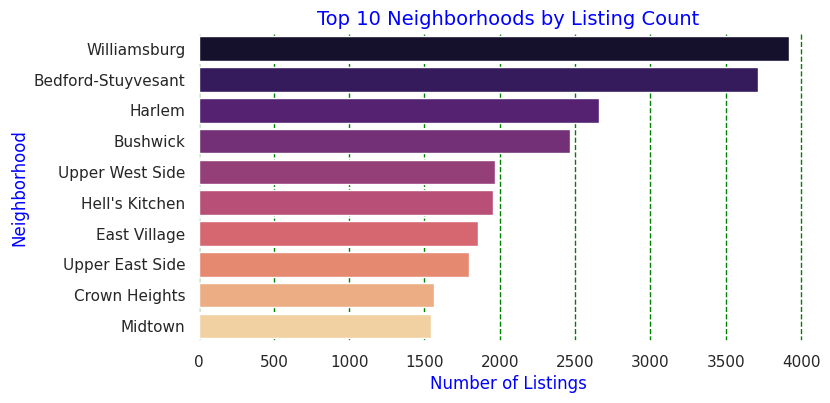

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
Hell's Kitchen,1958
East Village,1853
Upper East Side,1798
Crown Heights,1564


In [ ]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index,palette="magma")
plt.xlabel("Number of Listings", fontsize=12, color='blue')
plt.ylabel("Neighborhood", fontsize=12,color='blue')
plt.title("Top 10 Neighborhoods by Listing Count", fontsize=14,color='blue')
plt.grid(axis="x", linestyle='--', color='green')
ax=plt.gca()
ax.set_facecolor('white')
plt.show()
top_neighbourhoods

⚫$~~$ ***Key observation from "Top 10 Neighborhoods by Listing Count" barplot:-***

▶$~~$ Williamsburg	neighbourhood has the highest number of property-1376


▶$~~$ Greenpoint neighbourhood has few property among the top 10	-447

<ipython-input-16-5fd546cbe5ff>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='host_name', data=top_hosts, palette="magma")


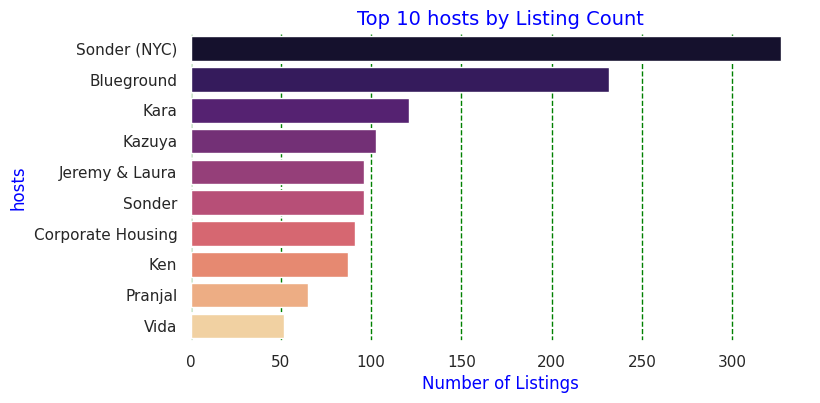

,host_id,host_name,count
34649,219517861,Sonder (NYC),327
29408,107434423,Blueground,232
19574,30283594,Kara,121
31080,137358866,Kazuya,103
14436,16098958,Jeremy & Laura,96
12806,12243051,Sonder,96
25663,61391963,Corporate Housing,91
17091,22541573,Ken,87
33871,200380610,Pranjal,65
9732,7503643,Vida,52


In [ ]:
top_hosts = df.groupby(['host_id', 'host_name'])['host_id'].count().reset_index(name='count').sort_values(by=['count'], ascending=False).head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x='count', y='host_name', data=top_hosts, palette="magma")
plt.xlabel("Number of Listings", fontsize=12, color='blue')
plt.ylabel("hosts", fontsize=12, color='blue')
plt.title("Top 10 hosts by Listing Count", fontsize=14, color='blue')
plt.grid(axis="x", linestyle='--', color='green')
ax=plt.gca()
ax.set_facecolor('white')
plt.show()
top_hosts

⚫$~~$ ***Key observation from "Top 10 hosts by Listing Count" barplot:-***

▶ 'Sonder'-219517861 has the highest number of property 327

▶$~~$ 'Vida'-7503643 has a small amount of property 52 among the top 10

# **12. $~$ Finding the Number of Active Hosts Per Location by Each Neighborhood Group.**

<ipython-input-28-b6c8df149807>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_hosts_per_group.index, y=active_hosts_per_group.values, palette="viridis")


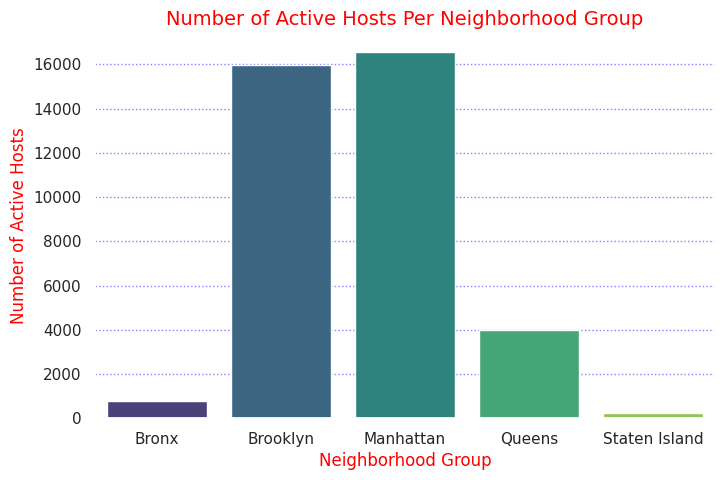

neighbourhood_group
Bronx              789
Brooklyn         15966
Manhattan        16578
Queens            3983
Staten Island      256
Name: host_id, dtype: int64


In [ ]:
active_hosts_per_group = df.groupby("neighbourhood_group")["host_id"].nunique()
plt.figure(figsize=(8, 5))
sns.barplot(x=active_hosts_per_group.index, y=active_hosts_per_group.values, palette="viridis")
plt.xlabel("Neighborhood Group",color='red' ,fontsize=12)
plt.ylabel("Number of Active Hosts",color='red' ,fontsize=12)
plt.title("Number of Active Hosts Per Neighborhood Group",color='red', fontsize=14)
plt.grid (axis="y",linestyle=':', color='blue', alpha=0.5)
ax=plt.gca()
ax.set_facecolor('white')
plt.show()
print(active_hosts_per_group)

⚫$~~$ ***Key observation from 'Number of Active Hosts Per Location by Neighborhood Group' barplot:-***

▶$~~$ Manhattan has the highest concentration of active hosts near (16578) compared to other boroughs.

▶$~~$ Staten Island has the keast number of active hosts (256) compared to others.  .



# **13.$~~$ Interactive map of Airbnb listings with prices,  locations and others:-**

In [ ]:
latitude_values=df['latitude']
longitude_values=df['longitude']
longitude_values
latitude_values

,latitude
0,40.64749
1,40.75362
2,40.80902
3,40.68514
4,40.79851
...,...
48890,40.67853
48891,40.70184
48892,40.81475
48893,40.75751


In [ ]:
# To see which location has maximum accomodation
location_counts = df.groupby(["latitude", "longitude"]).size().reset_index(name="count")
max_location = location_counts.loc[location_counts["count"].idxmax()]
max_location

,19823
latitude,40.71232
longitude,-73.94220
count,3.00000


In [ ]:
# Let's see that area in map
Long=-73.94220
Lat=40.71232
locations = list(zip(df.latitude, df.longitude))
map1 = folium.Map(location=[Lat,Long], zoom_start=9)
FastMarkerCluster(data=locations).add_to(map1)
map1.save("map1.html")
map1

In [ ]:
# To see distribution of Airbnb properties all over New York
fig = px.scatter_mapbox(df,
                           lat="latitude",
                           lon="longitude",
                           hover_name="name",
                           hover_data=["neighbourhood_group", "host_name", "room_type", "price","minimum_nights","availability_365"],
                           color="neighbourhood_group",
                           zoom=10,
                           height=600)
fig.update_layout(title_text="Distribution of Airbnb Properties", title_font_color="blue", title_x=0.5, title_xanchor='center', mapbox_style="open-street-map")
fig.show()

# **14.$~~~$ Finding stay requirement counts by minimum nights:-**

In [ ]:
# Count occurrences of all minimum nights values
minimum_nights_counts_all = df["minimum_nights"].value_counts()
minimum_nights_counts_all


,count
minimum_nights,
1,12720
2,11696
3,7999
30,3760
4,3303
...,...
186,1
366,1
68,1


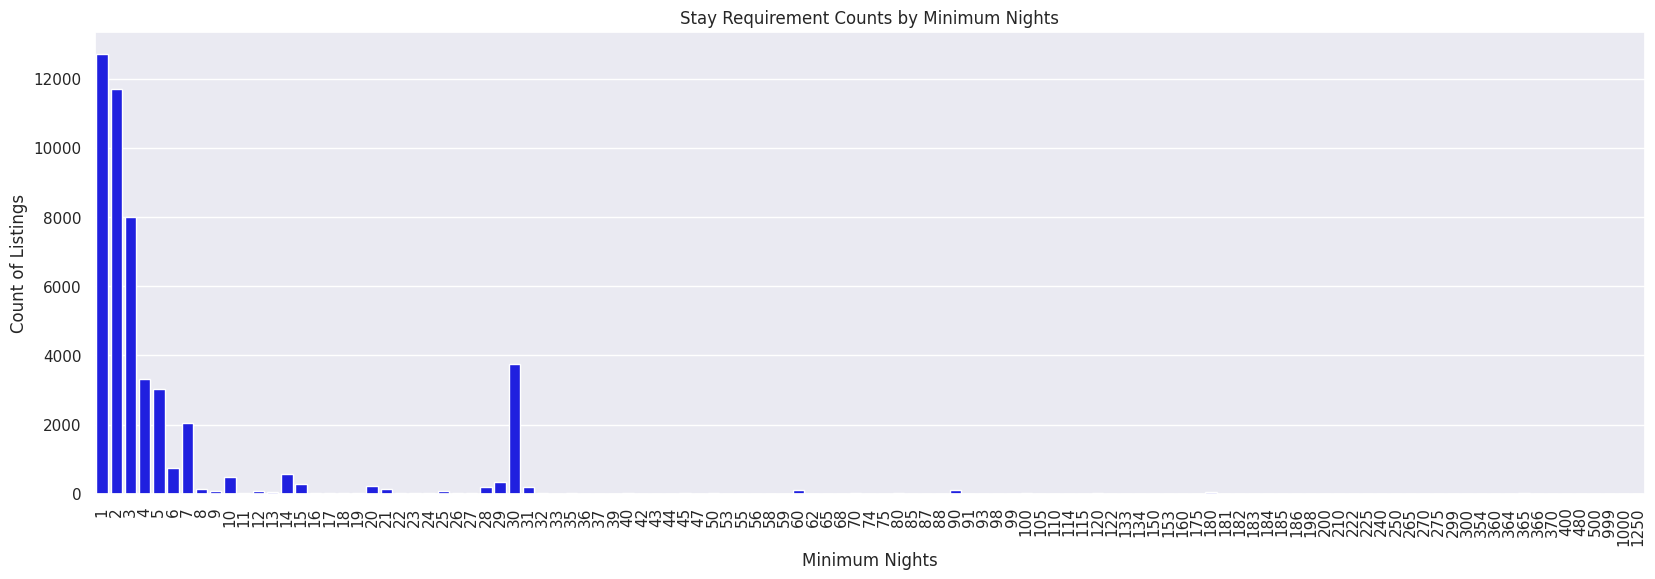

,count
minimum_nights,
1,12720
2,11696
3,7999
30,3760
4,3303
5,3034
7,2058
6,752
14,562


In [ ]:
bins = [1, 2, 3, 4, 5, 7, 10, 14,20, 30]
labels = ['1', '2', '3', '4', '5', '6-7', '8-10', '11-14','15-30']
df['nights_group'] = pd.cut(df['minimum_nights'], bins=bins, labels=labels)
minimum_nights_counts_binned = df["nights_group"].value_counts()
minimum_nights_counts_binned = df["minimum_nights"].value_counts().head(10)
plt.figure(figsize=(20, 6))
sns.barplot(x=minimum_nights_counts_all.index, y=minimum_nights_counts_all.values, color="blue")
plt.xlabel("Minimum Nights")
plt.ylabel("Count of Listings")
plt.title("Stay Requirement Counts by Minimum Nights")
plt.xticks(rotation=90)
plt.show()
minimum_nights_counts_binned

⚫$~~$ ***Key observation from "Stay Requirement Counts by Minimum Nights" barplot:-***

▶$~~$ Maximum staying capacity falls under 1-2 nights (12720-11696).

▶$~~$ The more nights someone wants to stay, the less accomodation will be get.

▶$~~$ But for 30 days there is some acoomodation option near about (3700).

# **15.$~~$ The total number of reviews and maximum reviews by each neighbourhood group:-**

In [ ]:
review_stats = df.groupby('neighbourhood_group')['number_of_reviews'].agg(['sum', 'max'])
review_stats = review_stats.reset_index()
review_stats = review_stats[['neighbourhood_group', 'sum', 'max']]
review_stats

,neighbourhood_group,sum,max
0,Bronx,28371,321
1,Brooklyn,486574,488
2,Manhattan,454569,607
3,Queens,156950,629
4,Staten Island,11541,333


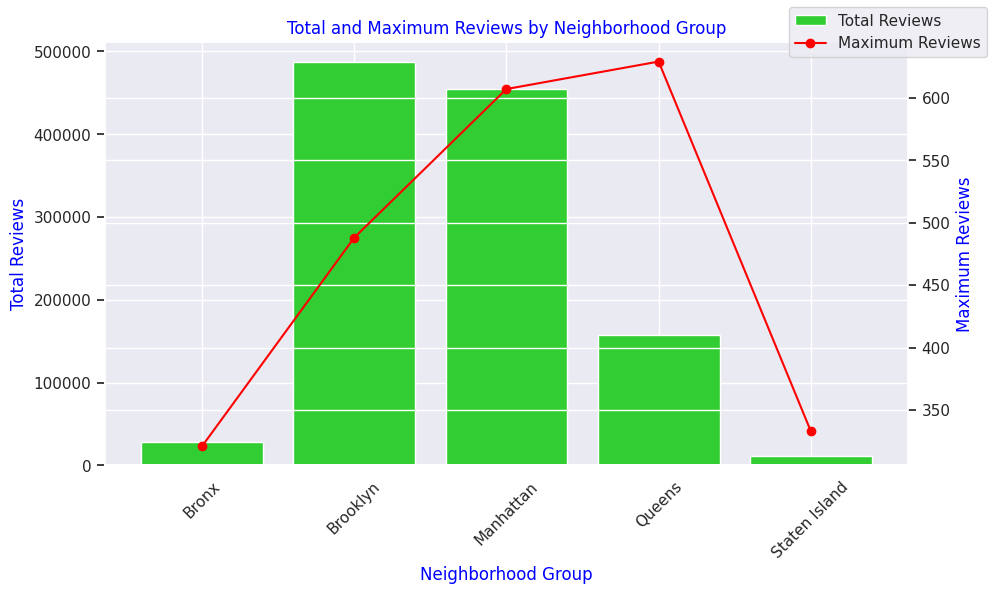

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(review_stats['neighbourhood_group'], review_stats['sum'], color='limegreen', label='Total Reviews')
ax1.set_xlabel('Neighborhood Group', color='blue')
ax1.set_ylabel('Total Reviews', color='blue')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(review_stats['neighbourhood_group'], review_stats['max'], color='red', marker='o', label='Maximum Reviews')
ax2.set_ylabel('Maximum Reviews', color='blue')
fig.legend(loc='upper right')
plt.title('Total and Maximum Reviews by Neighborhood Group', color='blue')
plt.tight_layout()
plt.show()

⚫$~~$ ***Key observation from 'Total and Maximum Reviews by Neighborhood Group' plot:-***

▶$~~$ Manhattan has the most frequently reviewed property among all the neighborhood groups.

# **16.$~~$ Most reviewed room type in neighbourhood groups per month:-**

In [ ]:
room_type_reviews = df.groupby(['neighbourhood_group', 'room_type'])['reviews_per_month'].sum()
room_type_reviews = room_type_reviews.reset_index()
most_reviewed_room_type = room_type_reviews.loc[room_type_reviews.groupby('neighbourhood_group')['reviews_per_month'].idxmax()]
most_reviewed_room_type

,neighbourhood_group,room_type,reviews_per_month
1,Bronx,Private room,1093.74
4,Brooklyn,Private room,12975.76
6,Manhattan,Entire home/apt,16244.92
10,Queens,Private room,6388.20
12,Staten Island,Entire home/apt,356.49


<ipython-input-45-8b458d547e10>:1: FutureWarning:

The provided callable <function sum at 0x7b9a52b31a80> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



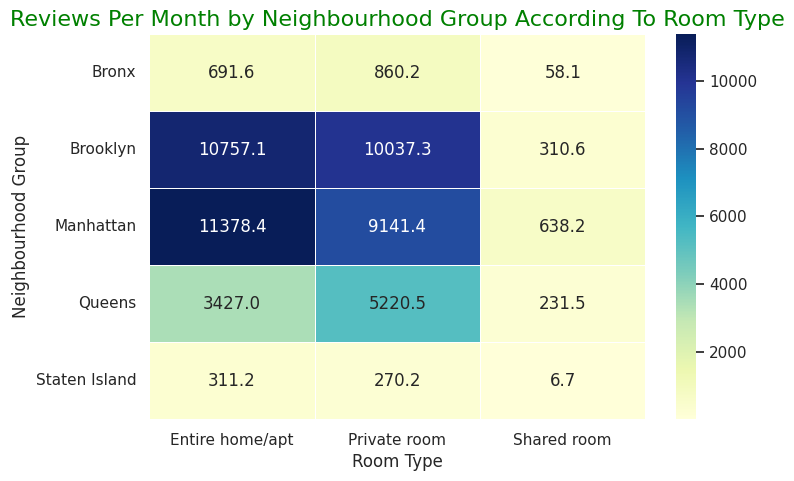

In [ ]:
pivot_table = df.pivot_table(values='reviews_per_month', index='neighbourhood_group', columns='room_type', aggfunc=np.sum, fill_value=0)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=0.5)
plt.title("Reviews Per Month by Neighbourhood Group According To Room Type", color='green', fontsize=16,)
plt.xlabel("Room Type")
plt.ylabel("Neighbourhood Group")
plt.show()

⚫$~~$ ***Key observation from "Reviews Per Month by Neighbourhood Group According To Room Type" heatmap:-***

▶$~~$ Most reviewed room type per month  is 'Entire home/apt' in 'Manhattan'- 16244.9

# **17.$~~$ The best location listing/property location for travellers:-**

In [ ]:
top_locations = df[(df['number_of_reviews'] > df['number_of_reviews'].quantile(0.75)) &
                   (df['availability_365'] > 200)]
best_neighbourhoods = top_locations.groupby('neighbourhood')[['number_of_reviews', 'availability_365', 'price']].mean()
best_neighbourhoods = best_neighbourhoods.sort_values(by='number_of_reviews', ascending=False)
best_neighbourhoods = best_neighbourhoods.head(10)
best_neighbourhoods

,number_of_reviews,availability_365,price
neighbourhood,,,
Battery Park City,205.000000,326.000000,55.000000
Mount Eden,201.500000,239.500000,42.500000
East Elmhurst,182.051282,322.641026,90.051282
Vinegar Hill,163.000000,201.000000,178.000000
Throgs Neck,163.000000,337.666667,108.000000
Concourse Village,157.000000,265.333333,85.000000
Cobble Hill,155.875000,278.250000,146.500000
DUMBO,149.500000,283.500000,188.250000
New Brighton,149.000000,276.000000,50.000000


<ipython-input-56-f461180315de>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_neighbourhoods.head(10), x=best_neighbourhoods.head(10).index, y="number_of_reviews", palette="viridis")


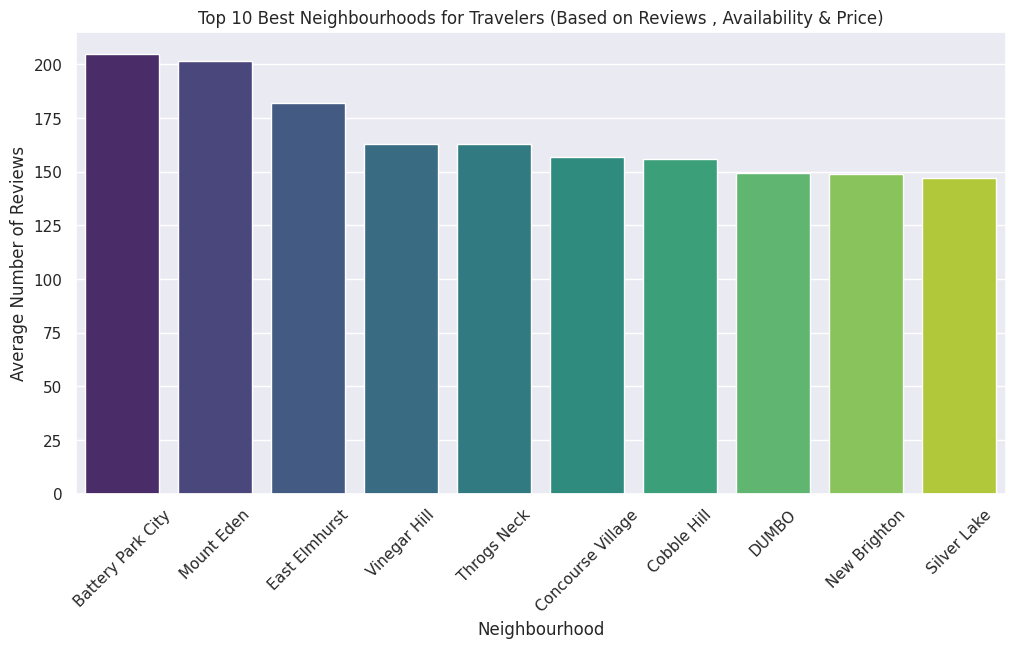

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=best_neighbourhoods.head(10), x=best_neighbourhoods.head(10).index, y="number_of_reviews", palette="viridis")
plt.title("Top 10 Best Neighbourhoods for Travelers (Based on Reviews , Availability & Price)")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=45)
plt.show()

⚫$~~$ ***Key observation from "Top 10 Best Neighbourhoods for Travelers (Based on Reviews , Availability & Price)" barplot:-***

▶$~~$ 'Battery Park City' should be the best choice for travellers because it has the highest number of reviews (205), moderate availability (326) and the price range ($ 55 ) which is very affordable.

# **18.$~~$ Best location listing/property location for hosts:-**

In [ ]:
top_host_locations = df.groupby('neighbourhood')[['price', 'number_of_reviews', 'availability_365']].mean()
best_host_neighbourhoods = top_host_locations.sort_values(by='price', ascending=False)
best_host_neighbourhoods.head(10)

,price,number_of_reviews,availability_365
neighbourhood,,,
Fort Wadsworth,800.000000,0.000000,365.000000
Woodrow,700.000000,0.000000,0.000000
Tribeca,490.638418,11.491525,126.508475
Sea Gate,487.857143,1.428571,65.571429
Riverdale,442.090909,26.636364,160.818182
Prince's Bay,409.500000,5.750000,110.500000
Battery Park City,367.557143,8.285714,100.328571
Flatiron District,341.925000,17.737500,123.050000
Randall Manor,336.000000,18.000000,275.210526


<ipython-input-59-85575dcf7437>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_host_neighbourhoods.head(10), x=best_host_neighbourhoods.head(10).index, y="price", palette="coolwarm")


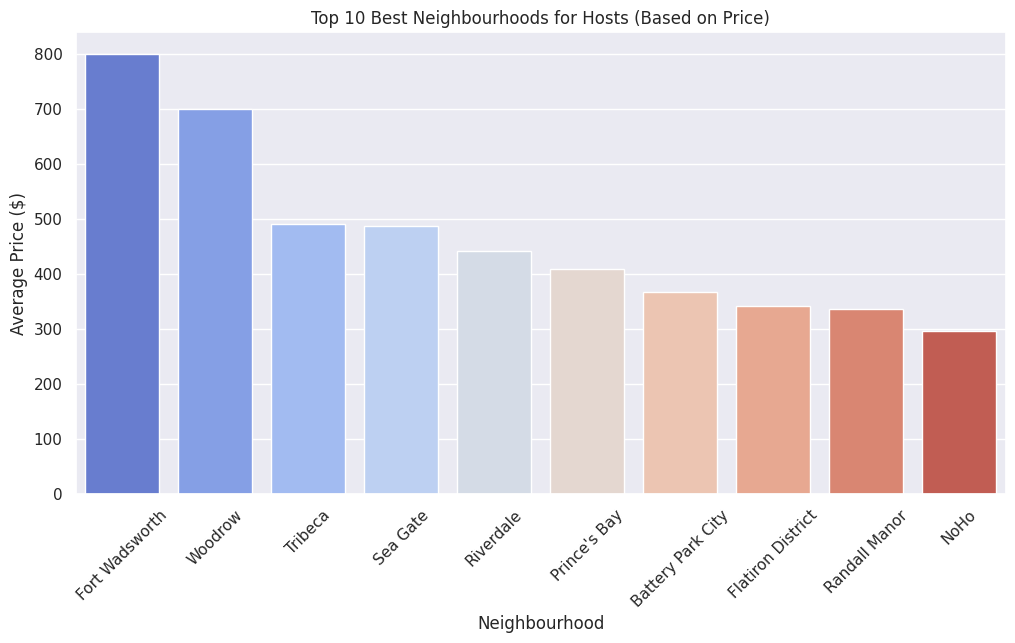

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=best_host_neighbourhoods.head(10), x=best_host_neighbourhoods.head(10).index, y="price", palette="coolwarm")
plt.title("Top 10 Best Neighbourhoods for Hosts (Based on Price)")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.show()

⚫$~~$ ***Key observation from "Top 10 Best Neighbourhoods for Hosts (Based on Price)" barplot:-***

▶$~~$ 'Fort Wadsworth' & 'Woodrow' have the highest average prices ( \$ 800 & \$ 700) but zero reviews, meaning they might not have many bookings.


▶$~~$ 'Tribeca' & 'Riverdale' have a good balance of high prices ( \$ 490.63 & \$ 442.09 ) & decent reviews(11 & 26), making them attractive locations for hosts.


▶$~~$  'Battery Park City' & 'Flatiron District' (\$ 367.55 & \$ 341.92 ) also show high pricing with decent availability (8 , 17), indicating good earning potential.


▶$~~$  'Randall Manor' ( \$ 336 ) stands out with 275 days of availability, making it an excellent long-term rental option.

# **19. $~~$ price variations in neighbourhood group:-**

<ipython-input-65-d611dd40fe00>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="neighbourhood_group", y="price", palette="viridis", inner="quartile")


(0.0, 355.0)

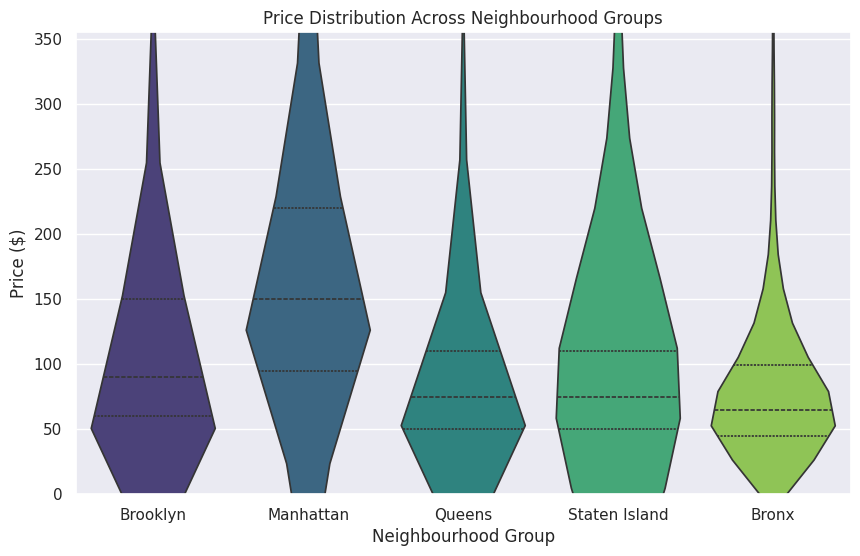

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="neighbourhood_group", y="price", palette="viridis", inner="quartile")
plt.title("Price Distribution Across Neighbourhood Groups")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.ylim(0, df["price"].quantile(0.95))

⚫$~~$ ***Key observation from "Price Distribution Across Neighbourhood Groups" violinplot:-***

▶$~~$ Manhattan is likely to have the highest-priced listings, including luxury stays.

# **20.$~~$ Now let's see if the price depends a bit on the reviews:-**

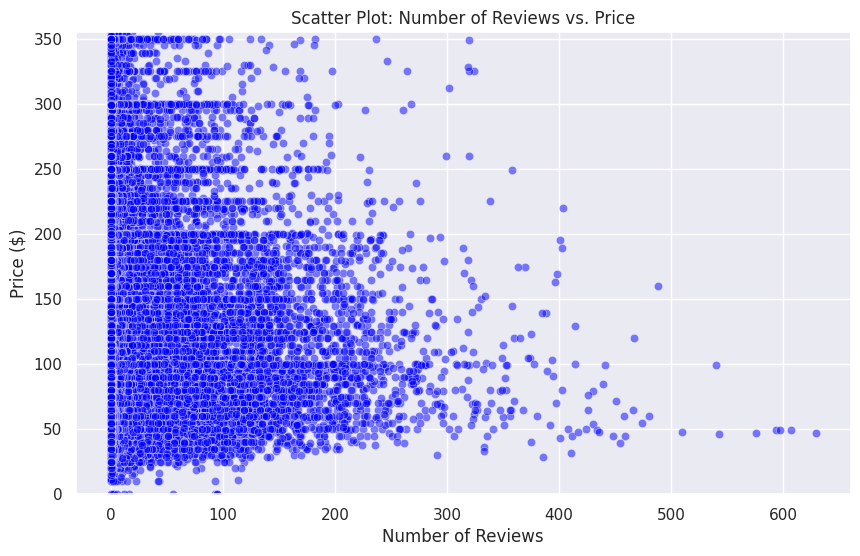

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="number_of_reviews", y="price", alpha=0.5, color="blue")
plt.title("Scatter Plot: Number of Reviews vs. Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.ylim(0, df["price"].quantile(0.95))
plt.show()

**⚛ There is no strong correlation between number of reviews and price, so price is not depending on review..**

# **21.$~~$ Cheapest & Expensive Airbnbs in New York:-**

In [ ]:
# To see Cheapest Property
cheapest = df.sort_values(by = 'price', ascending = True)
cheapest.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
26866,21304320,Best Coliving space ever! Shared room.,101970559,Sergii,Brooklyn,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.26,6,139


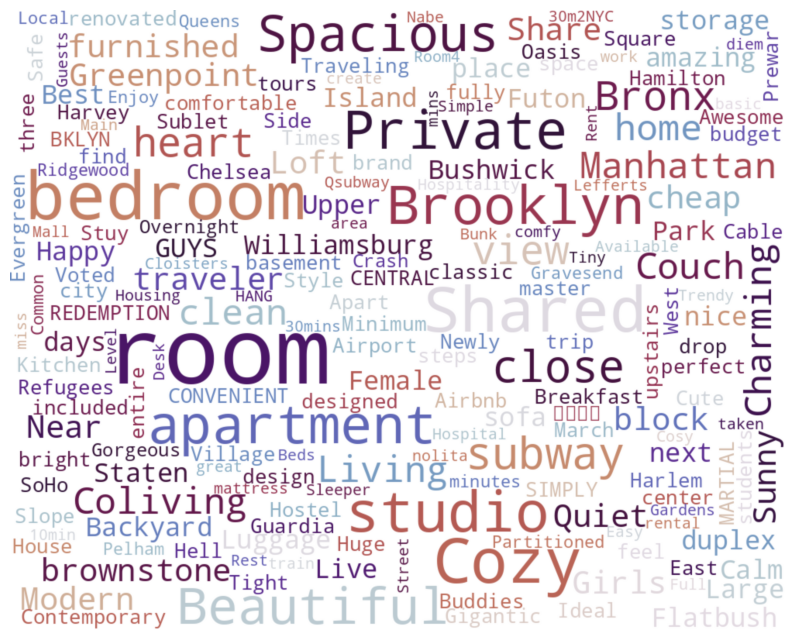

In [ ]:
# Most used words in cheapest property
cheapest = cheapest.head(100)
word_cloud = WordCloud(width = 1000,
                       height = 800,
                       colormap = 'twilight_shifted',
                       margin = 0,
                       max_words = 200,
                       min_word_length = 4,
                       max_font_size = 120, min_font_size = 15,
                       background_color = "white").generate(" ".join(cheapest['name']))
plt.figure(figsize = (10, 15))
plt.imshow(word_cloud, interpolation = "gaussian")
plt.axis("off")
plt.show()

In [ ]:
# To see Luxury Property
expensive = df.sort_values(by = 'price', ascending = False)
expensive.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaN,NaN,1,365
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,18128455,Rum,Manhattan,Tribeca,40.72197,-74.00633,Entire home/apt,8500,30,2,2018-09-18,0.18,1,251
4377,2953058,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,2016-09-15,0.03,11,365
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.76824,-73.95989,Entire home/apt,7703,1,0,NaN,NaN,12,146
42523,33007610,70' Luxury MotorYacht on the Hudson,7407743,Jack,Manhattan,Battery Park City,40.71162,-74.01693,Entire home/apt,7500,1,0,NaN,NaN,1,364


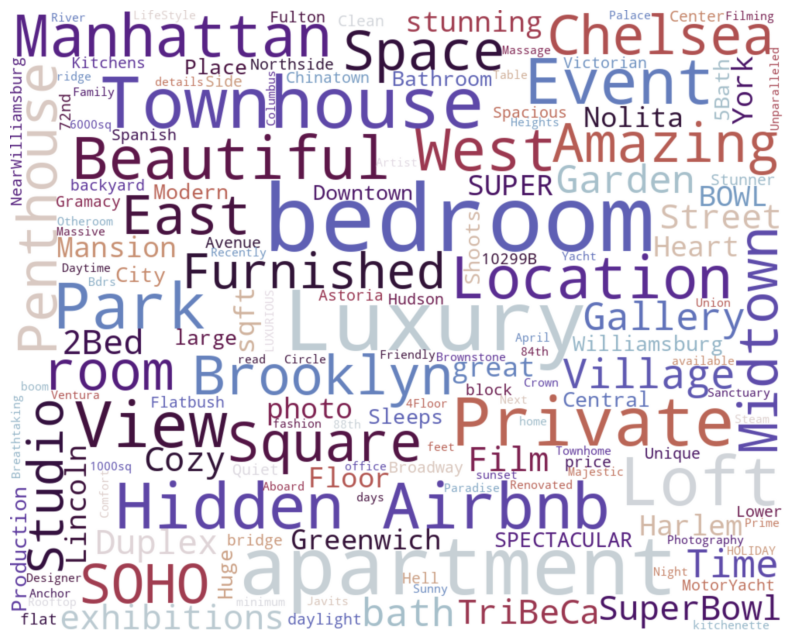

In [ ]:
# Most used words in luxury property
expensive = expensive.head(100)
word_cloud = WordCloud(width = 1000,
                       height = 800,
                       colormap = 'twilight_shifted',
                       margin = 0,
                       max_words = 200,
                       min_word_length = 4,
                       max_font_size = 120, min_font_size = 15,
                       background_color = "white").generate(" ".join(expensive['name']))
plt.figure(figsize = (10, 15))
plt.imshow(word_cloud, interpolation = "gaussian")
plt.axis("off")
plt.show()

**Notes ::**

Comparing the words used in the names of the cheapest and most expensive Airbnbs in New York, we can see that the cheapest Airbnbs use words like'Subway', 'Studio', 'Room', 'Beautiful', 'Cozy', 'Spacious', 'Shared' and 'Cheap'

 while the expensive Airbnbs use words like 'Townhouse', 'Luxury', 'Location', 'Hidden', 'Park', 'SOHO' and 'Penthouse'.


People who choose cheap Airbnbs generally look for properties which are spacious, cosy, cheap and near to the subway station as it reduces the transport cost and brings down the overall cost of their trip while people who prefer luxurious Airbnbs option,  because of privacy (peaceful and secluded from crowded places), comfort and location (close to famous landmarks such as 'Central Park').

# **⬛ Key Conclusions :-**
Based on the analysis of Airbnb listings, here are the major insights:

**1.$~~$  Price Variations Across Neighbourhood Groups**

✅ Manhattan and Brooklyn tend to have higher average prices, likely due to premium listings and high demand.

✅ The Bronx and Staten Island offer more affordable stays, making them attractive for budget travelers.

✅ Luxury listings in areas like Tribeca & Battery Park City significantly inflate price distributions.


**2.$~~$ Most Popular Room Type**

✅ Entire homes/apartments dominate high-priced listings.

✅ Private rooms  are more affordable and attract budget-conscious travelers.

✅ Shared rooms and hotel rooms have the lowest count and demand.


**3.$~~$  Reviews & Price Relationship**

✅ No strong correlation: High reviews ≠ High price.

✅ Budget listings tend to receive more reviews due to higher occupancy rates.

✅ Luxury properties have fewer but high-value reviews.


**4.$~~$  Best Locations for Travelers**

✅ Tourists prefer areas with good connectivity, safety, and attractions.

✅ Manhattan and Brooklyn are preferred for their central locations.

✅ The Bronx & Staten Island attract travelers looking for budget stays.


**5.$~$  Best Locations for Hosts (Profitable Areas)**

✅ Manhattan and Brooklyn hosts earn more due to high demand.

✅ Areas with high review counts indicate consistent bookings.

✅ Hosts in budget-friendly areas (Bronx, Queens) benefit from high occupancy rates.


**6.$~~$  Availability and Demand**

✅ Listing with high availability (availability_365 > 200 days) are more likely to be long-term rental properties.

✅ Properties with low availability and high prices are usually exclusive, luxury, or seasonal rentals.
